# 02 — Feature Engineering Exploration

Explores the engineered feature matrix produced by Modules 3–5
(RDKit descriptors → feature engineering → osmotic correction).

Covers:
- Feature inventory by category (concentration, compound, descriptor, interaction, bio-score)
- Feature/feature and feature/target correlation
- Variance and near-zero-variance feature check
- Tanimoto similarity matrix visualisation
- Osmotic inhibition score sanity check
- PCA projection of the feature space

**Inputs:** `data/features/osmotic_corrected_matrix.csv`,
`data/features/full_matrix_with_targets.csv`,
`data/features/feature_engineering_log.json`,
`data/descriptors/tanimoto_matrix.csv`

Run Modules 3–5 first if these files don't exist yet:
```bash
python src/module_03_descriptors.py
python src/module_04_features.py
python src/module_05_osmotic.py
```

In [11]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, "../src")
from utils import load_config, load_json

PROJECT_ROOT = Path("..")
config = load_config(str(PROJECT_ROOT / "config" / "config.yaml"))

plt.style.use(config["FIGURES"].get("style", "seaborn-v0_8-whitegrid"))
sns.set_palette(config["FIGURES"].get("color_palette", "colorblind"))

FEATURE_PATH = PROJECT_ROOT / "data" / "features" / "osmotic_corrected_matrix.csv"
FULL_PATH = PROJECT_ROOT / "data" / "features" / "full_matrix_with_targets.csv"
LOG_PATH = PROJECT_ROOT / "data" / "features" / "feature_engineering_log.json"
TANIMOTO_PATH = PROJECT_ROOT / "data" / "descriptors" / "tanimoto_matrix.csv"

assert FEATURE_PATH.exists(), (
    f"'{FEATURE_PATH}' not found. Run Modules 3, 4, and 5 first."
)

feat_df = pd.read_csv(FEATURE_PATH)
full_df = pd.read_csv(FULL_PATH) if FULL_PATH.exists() else feat_df.copy()
print(f"Feature matrix: {feat_df.shape[0]} rows × {feat_df.shape[1]} features")
feat_df.head()

Feature matrix: 281 rows × 73 features


,compound_lantadene_a,compound_lantadene_b,compound_lantadene_c,compound_lantadene_d,compound_icterogenin,compound_luteolin,compound_hispidulin,compound_quercetin,compound_kaempferol,compound_caffeic_acid,...,species_donor_ageratina_adenophora,species_donor_chromolaena_odorata,species_donor_eucalyptus_globulus,species_donor_lantana_camara,species_donor_other,species_donor_parthenium_hysterophorus,incubation_temp_c,incubation_days,osmotic_inhibition_score,osmotic_correction_approximate
0,0.892148,0.811766,0.742957,0.908484,0.724124,0.793308,0.926446,0.423967,0.728917,0.464321,...,0.0,0.0,0.0,1.0,0.0,0.0,25.0,7,0.0,0.0
1,0.899199,0.882684,0.711785,0.814743,0.965776,0.773192,0.784353,0.431373,0.867242,0.463071,...,0.0,0.0,0.0,1.0,0.0,0.0,25.0,7,0.0,1.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.350283,...,0.0,0.0,1.0,0.0,0.0,0.0,25.0,7,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.529412,0.000000,0.525175,...,1.0,0.0,0.0,0.0,0.0,0.0,25.0,7,0.0,0.0
4,0.876085,0.846010,0.868811,0.701252,0.758973,0.861580,0.864259,0.443471,0.908433,0.528510,...,0.0,0.0,0.0,1.0,0.0,0.0,25.0,7,0.0,1.0


## 1. Feature inventory by category

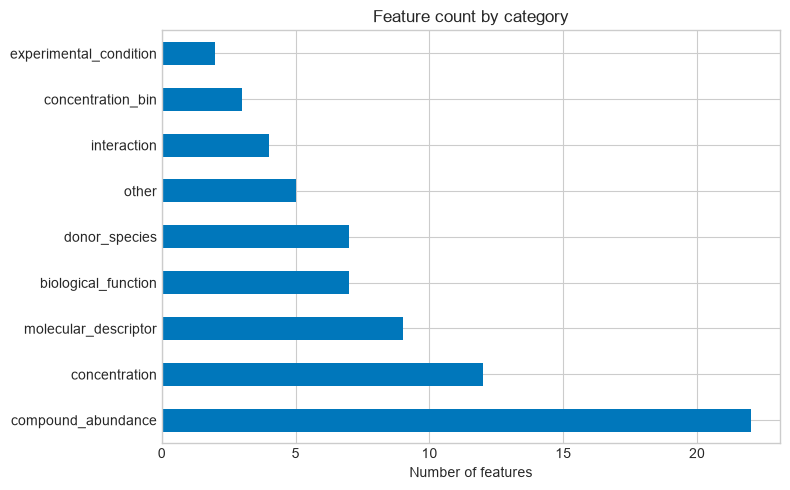

compound_abundance        22
concentration             12
molecular_descriptor       9
biological_function        7
donor_species              7
other                      5
interaction                4
concentration_bin          3
experimental_condition     2
Name: count, dtype: int64

In [12]:
if LOG_PATH.exists():
    feat_log = load_json(str(LOG_PATH))
    categories = feat_log["feature_categories"]
    cat_counts = pd.Series(categories).value_counts()
else:
    # Fallback: infer categories from column name prefixes
    def infer_category(col):
        if col.startswith("concentration") or col.startswith("conc_bin"):
            return "concentration"
        if col.startswith("compound_"):
            return "compound_abundance"
        if col.startswith("agg_"):
            return "molecular_descriptor"
        if col.startswith("bio_score_"):
            return "biological_function"
        if "_x_" in col:
            return "interaction"
        if col in ("incubation_temp_c", "incubation_days"):
            return "experimental_condition"
        if col.startswith(("part_", "solvent_", "method_", "crop_")):
            return "experimental_condition_encoded"
        return "other"
    categories = {c: infer_category(c) for c in feat_df.columns}
    cat_counts = pd.Series(categories).value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
cat_counts.plot(kind="barh", ax=ax, color="#0077BB")
ax.set_xlabel("Number of features")
ax.set_title("Feature count by category")
plt.tight_layout()
plt.show()

cat_counts

## 2. Variance and near-zero-variance check

Features with near-zero variance contribute little signal and may be candidates for removal.

Features with near-zero variance (<1e-06): 4
max_tanimoto_to_known_bioactive    0.0
incubation_temp_c                  0.0
osmotic_inhibition_score           0.0
incubation_days                    0.0
dtype: float64


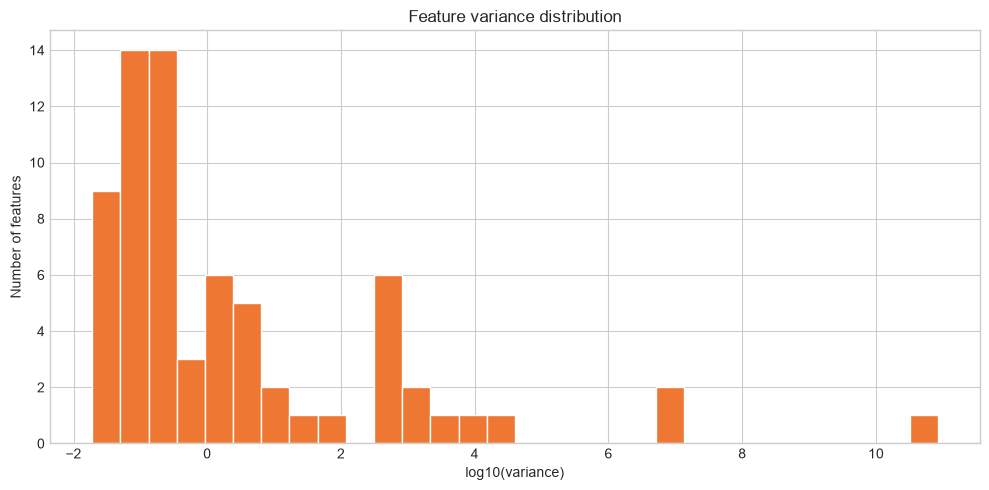

In [13]:
numeric_feat_df = feat_df.select_dtypes(include=[np.number])
variances = numeric_feat_df.var().sort_values()

low_variance_threshold = 1e-6
low_var_features = variances[variances < low_variance_threshold]
print(f"Features with near-zero variance (<{low_variance_threshold}): {len(low_var_features)}")
if len(low_var_features) > 0:
    print(low_var_features)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log10(variances.replace(0, np.nan).dropna()), bins=30, edgecolor="white", color="#EE7733")
ax.set_xlabel("log10(variance)")
ax.set_ylabel("Number of features")
ax.set_title("Feature variance distribution")
plt.tight_layout()
plt.show()

## 3. Feature/target correlation

Which engineered features correlate most strongly with each endpoint?

In [14]:
ENDPOINTS = ["germination_percent", "root_length_mm", "shoot_length_mm"]
present_endpoints = [e for e in ENDPOINTS if e in full_df.columns]
feature_cols = [c for c in feat_df.columns if feat_df[c].dtype != object]

corr_records = []
for ep in present_endpoints:
    y = full_df[ep]
    valid_idx = y.dropna().index
    for col in feature_cols:
        x = feat_df.loc[valid_idx, col]
        y_valid = y.loc[valid_idx]
        if x.std() > 0 and y_valid.std() > 0:
            r = np.corrcoef(x, y_valid)[0, 1]
            corr_records.append({"endpoint": ep, "feature": col, "correlation": r})

corr_df = pd.DataFrame(corr_records)
corr_df.head()

,endpoint,feature,correlation
0,germination_percent,compound_lantadene_a,0.075587
1,germination_percent,compound_lantadene_b,0.085304
2,germination_percent,compound_lantadene_c,0.085035
3,germination_percent,compound_lantadene_d,0.077863
4,germination_percent,compound_icterogenin,0.076296


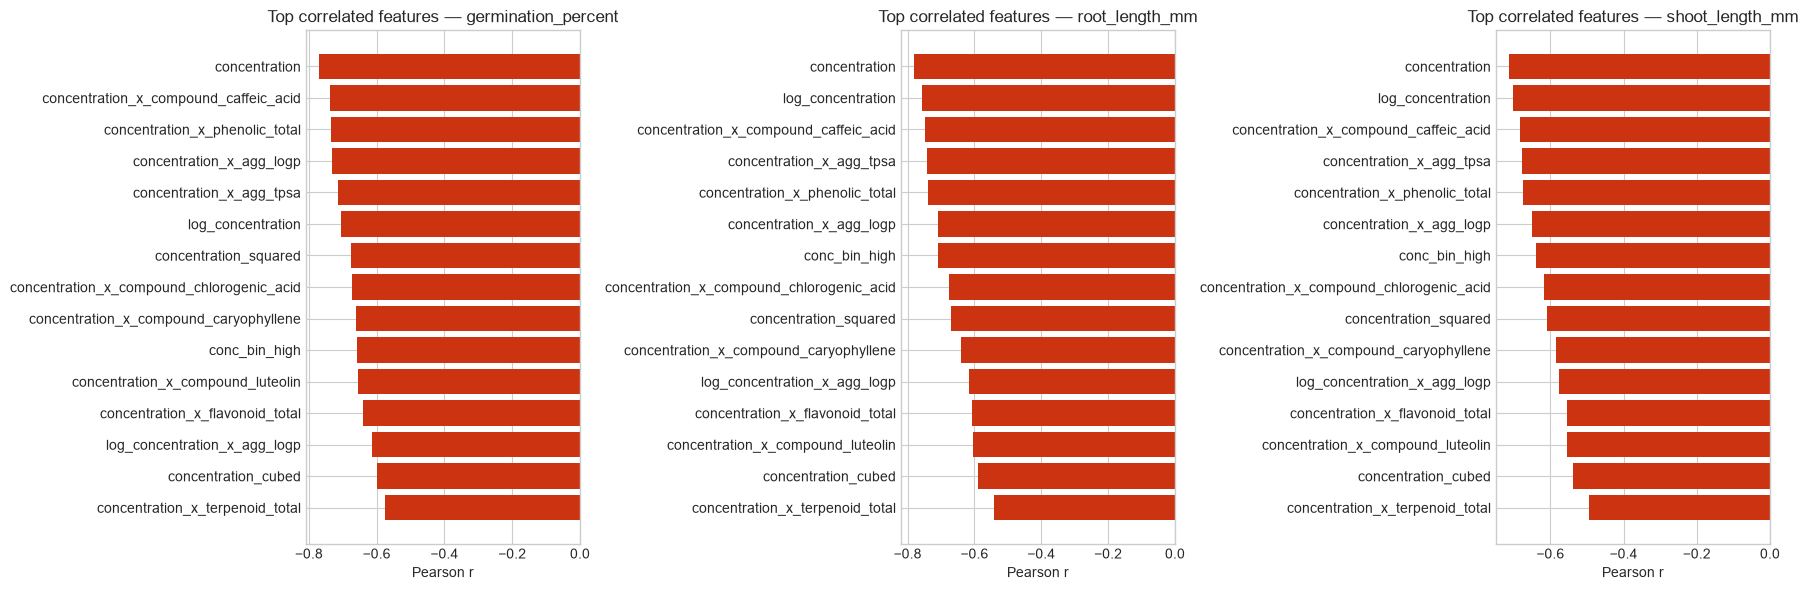

In [15]:
if not corr_df.empty:
    fig, axes = plt.subplots(1, len(present_endpoints), figsize=(6 * len(present_endpoints), 6), squeeze=False)
    for ax, ep in zip(axes[0], present_endpoints):
        top = (
            corr_df[corr_df["endpoint"] == ep]
            .reindex(corr_df[corr_df["endpoint"] == ep]["correlation"].abs().sort_values(ascending=False).index)
            .head(15)
        )
        colors = ["#cc3311" if v < 0 else "#0077BB" for v in top["correlation"]]
        ax.barh(top["feature"], top["correlation"], color=colors)
        ax.set_title(f"Top correlated features — {ep}")
        ax.set_xlabel("Pearson r")
        ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No correlations computed — check that target columns are present.")

## 4. Concentration vs. endpoints (raw dose-response shape)

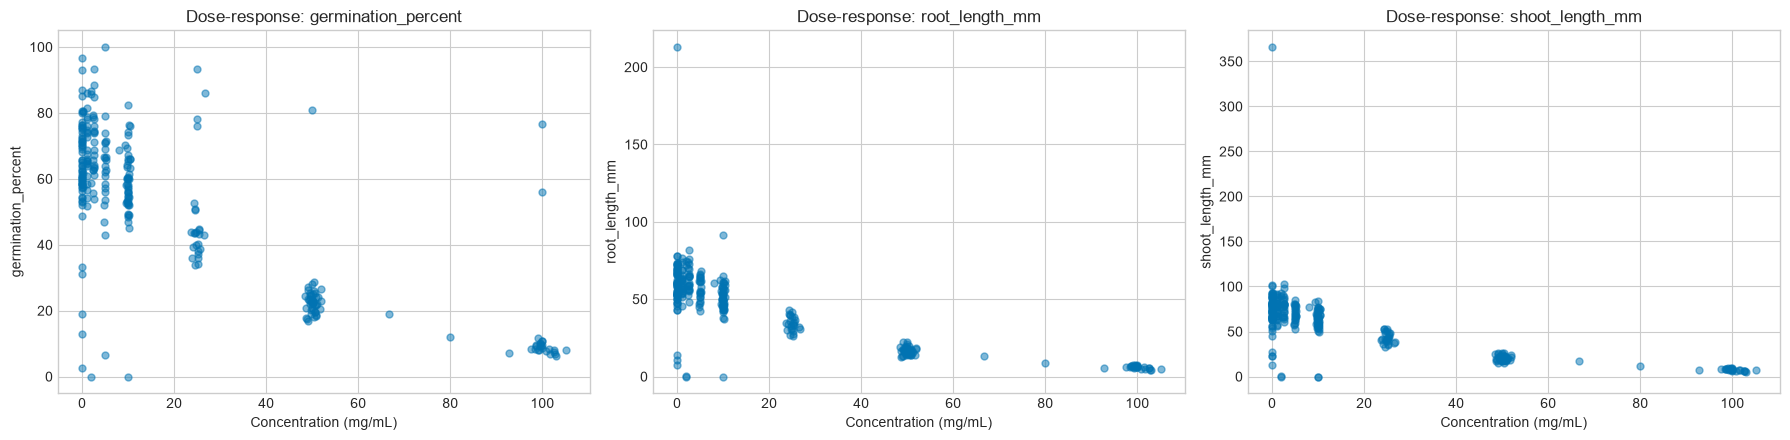

In [16]:
if "concentration" in feat_df.columns:
    fig, axes = plt.subplots(1, len(present_endpoints), figsize=(6 * len(present_endpoints), 4.5), squeeze=False)
    for ax, ep in zip(axes[0], present_endpoints):
        valid = full_df[ep].notna()
        ax.scatter(feat_df.loc[valid, "concentration"], full_df.loc[valid, ep], alpha=0.5, s=25)
        ax.set_xlabel("Concentration (mg/mL)")
        ax.set_ylabel(ep)
        ax.set_title(f"Dose-response: {ep}")
    plt.tight_layout()
    plt.show()

## 5. Tanimoto similarity matrix

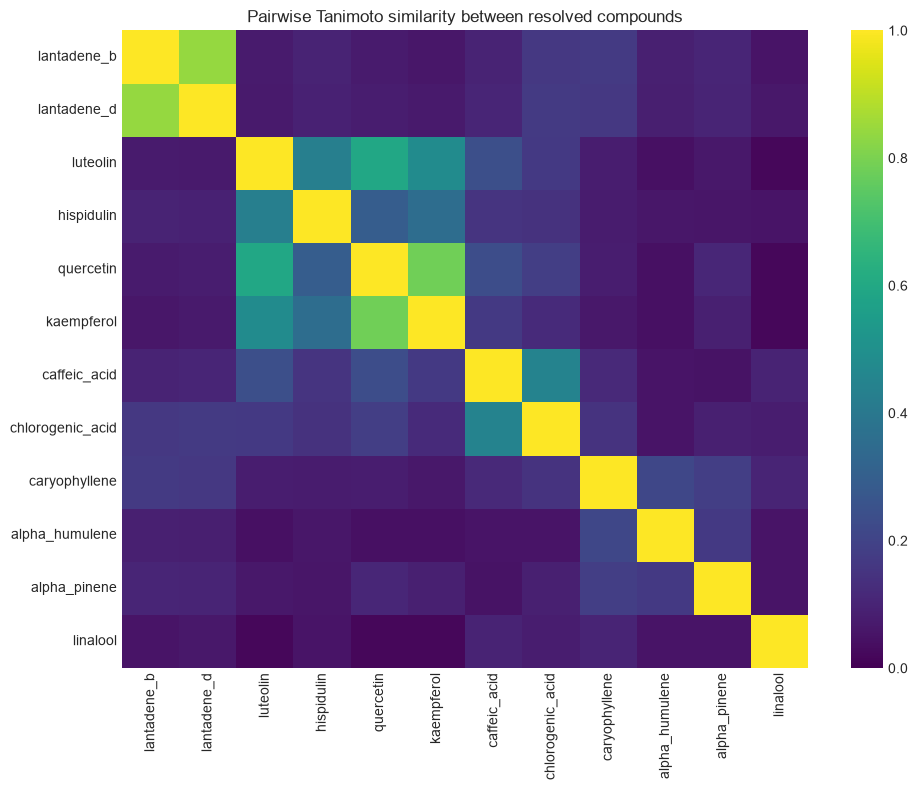

In [17]:
if TANIMOTO_PATH.exists():
    tanimoto_df = pd.read_csv(TANIMOTO_PATH, index_col=0)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(tanimoto_df, annot=False, cmap="viridis", vmin=0, vmax=1,
                xticklabels=[c.replace("compound_", "") for c in tanimoto_df.columns],
                yticklabels=[c.replace("compound_", "") for c in tanimoto_df.index],
                ax=ax)
    ax.set_title("Pairwise Tanimoto similarity between resolved compounds")
    plt.tight_layout()
    plt.show()
else:
    print("No tanimoto_matrix.csv found — fewer than 2 resolved fingerprints, or Module 3 not yet run.")

## 6. Osmotic inhibition score sanity check

This score should trend more negative (more inhibitory) as concentration increases.

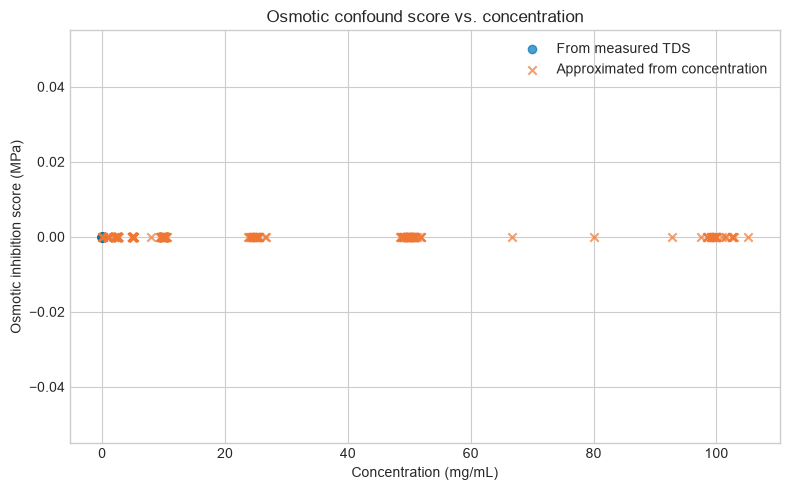

⚠️  225/281 rows used the APPROXIMATE osmotic correction (no measured TDS data). Treat high-concentration predictions with extra caution.


In [18]:
if "osmotic_inhibition_score" in feat_df.columns and "concentration" in feat_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    approx_mask = feat_df.get("osmotic_correction_approximate", pd.Series(0, index=feat_df.index)) == 1
    ax.scatter(feat_df.loc[~approx_mask, "concentration"],
               feat_df.loc[~approx_mask, "osmotic_inhibition_score"],
               label="From measured TDS", alpha=0.7, color="#0077BB")
    ax.scatter(feat_df.loc[approx_mask, "concentration"],
               feat_df.loc[approx_mask, "osmotic_inhibition_score"],
               label="Approximated from concentration", alpha=0.7, color="#EE7733", marker="x")
    ax.set_xlabel("Concentration (mg/mL)")
    ax.set_ylabel("Osmotic inhibition score (MPa)")
    ax.set_title("Osmotic confound score vs. concentration")
    ax.legend()
    plt.tight_layout()
    plt.show()

    n_approx = int(approx_mask.sum())
    if n_approx > 0:
        print(f"⚠️  {n_approx}/{len(feat_df)} rows used the APPROXIMATE osmotic correction "
              f"(no measured TDS data). Treat high-concentration predictions with extra caution.")
else:
    print("Osmotic features not found — run Module 5 first.")

## 7. PCA projection of the feature space

A 2D PCA view helps spot clusters, outliers, or batch effects across studies/extraction methods.

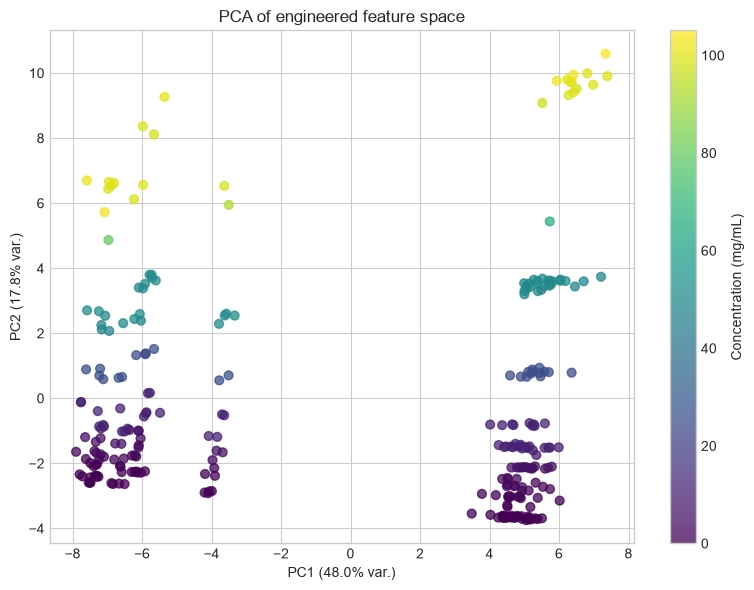

Cumulative variance explained by PC1+PC2: 65.8%


In [19]:
numeric_cols = feat_df.select_dtypes(include=[np.number]).columns

# 2. Safety filter: drop columns that are completely NaN or have zero variance
X = feat_df[numeric_cols].dropna(how="all", axis=1)  # Drop fully empty columns
X = X.loc[:, X.var() > 0]  # Drop columns with zero variance (all identical values)

X = X.fillna(X.mean()).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=config["RANDOM_SEED"])
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                 c=feat_df["concentration"] if "concentration" in feat_df.columns else None,
                 cmap="viridis", alpha=0.75, s=40)
if "concentration" in feat_df.columns:
    plt.colorbar(sc, ax=ax, label="Concentration (mg/mL)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)")
ax.set_title("PCA of engineered feature space")
plt.tight_layout()
plt.show()

print(f"Cumulative variance explained by PC1+PC2: {pca.explained_variance_ratio_.sum():.1%}")

## 8. Notes for next stage

Things worth flagging before training:

- Any feature with near-zero variance (Section 2) — consider dropping
- Features that show suspiciously high |correlation| (>0.95) with a single
  endpoint, which could indicate leakage from a derived column
- Rows that sit as clear outliers in the PCA projection — check their
  source study for data entry errors
- Confirm the osmotic correction approximate-rate isn't too high; if so,
  prioritise studies that report TDS/electrical conductivity directly

Proceed to `03_model_comparison.ipynb` once the feature matrix looks sound.